In [ ]:
import marimo as mo

# Setup

In [ ]:
# imports for study design step (Step 1)
import numpy as np
import pandas as pd
from scipy import stats
from scipy import optimize
import matplotlib.pyplot as plt

# imports for GP regression (Step 3)
import gpflow

# imports for Bayes opt (Step 4-6)
import trieste
from trieste.space import Box
from trieste.models.gpflow.models import GaussianProcessRegression
import tensorflow as tf
from trieste.experimental.plotting import plot_regret

/opt/venv/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
from py_group_sequential_designs import generate_boundaries as bd
from py_group_sequential_designs import feasibility_penalty as fp
from py_group_sequential_designs import boundary_manipulations as fmt_bd
from py_group_sequential_designs import function_to_minimize as fn_min
from py_group_sequential_designs import generate_gpr_input as gen_input
from py_group_sequential_designs import simulate as sim
from py_group_sequential_designs import sample_size as ss

# Bayes opt defaults - three stage design

In [ ]:
# some set defaults
num_analyses = 3
target_alpha = 0.05
target_power = 0.9
important_diff_delta = 1
assumed_variance = 3

# to obtain mu (sample size at one stage)
mu = ss.sample_size_means(
    ratio=1,
    variance=assumed_variance,
    power=target_power,
    alpha=target_alpha,
    delta=important_diff_delta
)

## Generate X, Y helper function

In [ ]:
# create a function that generates the points x and y that will be
# included in the design matrix X and Y
def generate_x_y(
        mu,
        upper_bounds,
        lower_bounds,
        n_analyses,
        target_power,
        target_alpha,
        alpha_prime,
        beta_prime,
        n_power09):

    # 2. Generate the GPR input values
    # note that the input includes the sample size at power 0.9
    x = gen_input.generate_gpr_input(
        n_analyses = n_analyses,
        upper_bounds=upper_bounds,
        lower_bounds=lower_bounds,
        n_patients=n_power09)

    # 3. Generate maximum expected sample size and feasibility penalty
    max_ess_new = ss.max_ess(
        n_analyses=n_analyses,
        upper_bounds=upper_bounds,
        lower_bounds=lower_bounds,
        n_patients=n_power09)

    penalty = fp.smooth_penalty(
        mu = mu,
        power=target_power,
        alpha=target_alpha,
        beta_prime=beta_prime,
        alpha_prime=alpha_prime
    )

    # 4. Calculate the function value (GPR output)
    y = fn_min.function_to_minimize(max_ess_val=max_ess_new/mu, penalty=penalty)

    return (np.array([x]), np.array([[y]]))

In [ ]:
# this function contains a penalty for non-monotonicity
def generate_x_y_new(
        mu,
        upper_bounds,
        lower_bounds,
        n_analyses,
        target_power,
        target_alpha,
        alpha_prime,
        beta_prime,
        n_power09):

    # 2. Generate the GPR input values
    # note that the input includes the sample size at power 0.9
    x = gen_input.generate_gpr_input(
        n_analyses = n_analyses,
        upper_bounds=upper_bounds,
        lower_bounds=lower_bounds,
        n_patients=n_power09)

    # 3. Generate maximum expected sample size and feasibility penalty
    max_ess_new = ss.max_ess(
        n_analyses=n_analyses,
        upper_bounds=upper_bounds,
        lower_bounds=lower_bounds,
        n_patients=n_power09)

    penalty = fp.smooth_penalty(
        mu = mu,
        power=target_power,
        alpha=target_alpha,
        beta_prime=beta_prime,
        alpha_prime=alpha_prime
    )

    # 4. Calculate the function value (GPR output)
    if fmt_bd.check_monotonicity(n_analyses=num_analyses, bounds=x) == False:
        y = 25
    else: 
        y = fn_min.function_to_minimize(max_ess_val=max_ess_new/mu, penalty=penalty)

    return (np.array([x]), np.array([[y]]))

The above penalty function is modified by dividing the maximum expected sample size by $\mu$, which is the sample size for a single stage design. This change was made because the Bayesian optimization algorithm was favoring minimization of the sample size parameter  most (always outputting values at the lower bound of the search space).

## First 3 points for Bayes opt initialization

### Pocock - point 1

In [ ]:
# simulate the trial design 
poc_simulation = bd.calculate_pocock_boundaries(
    n_analyses=num_analyses,
    alpha=target_alpha,
    n_patients=20
)

# find the number of patients that achieves 90% power (beta 0.1)
# here we get beta_prime
poc_n_power09, poc_power = ss.find_sample_size(
    n_analyses = num_analyses,
    upper_bounds = poc_simulation[0],
    lower_bounds = poc_simulation[1],
    alt_hypothesis = important_diff_delta,
    variance = assumed_variance
)

x1, y1 = generate_x_y(
    mu = mu,
    upper_bounds = poc_simulation[0],
    lower_bounds = poc_simulation[1],
    n_analyses = num_analyses,
    target_power = target_power,
    target_alpha = target_alpha,
    alpha_prime = poc_simulation[3],
    beta_prime = 1-poc_power,
    n_power09 = poc_n_power09
)

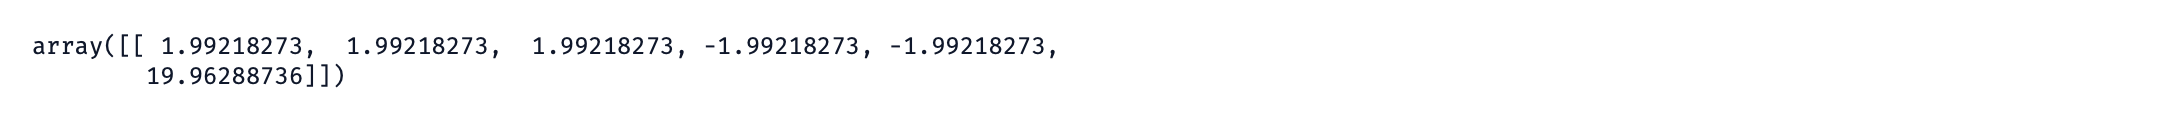

In [ ]:
x1

### O'Brien-Fleming - point 2

In [ ]:
# simulate the trial design 
of_simulation = bd.calculate_of_boundaries(
    n_analyses=num_analyses,
    alpha=target_alpha,
    n_patients=20
)

# find the number of patients that achieves 90% power (beta 0.1) and beta_prime
of_n_power09, of_power = ss.find_sample_size(
    n_analyses = num_analyses,
    upper_bounds = of_simulation[0],
    lower_bounds = of_simulation[1],
    alt_hypothesis = important_diff_delta,
    variance = assumed_variance
)

x2, y2 = generate_x_y(
    mu = mu,
    upper_bounds = of_simulation[0],
    lower_bounds = of_simulation[1],
    n_analyses = num_analyses,
    target_power = target_power,
    target_alpha = target_alpha,
    alpha_prime = of_simulation[3],
    beta_prime = 1-of_power,
    n_power09 = of_n_power09
)

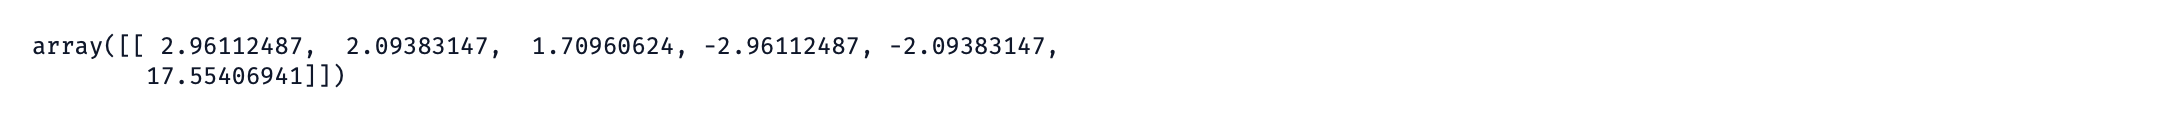

In [ ]:
x2

### Triangular - point 3

In [ ]:
# simulate the trial design 
tri_simulation = bd.calculate_triangular_boundaries(
    n_analyses=num_analyses,
    alpha=target_alpha,
    delta=important_diff_delta,
    n_patients=20
)

# find the number of patients that achieves 90% power (beta 0.1) and beta_prime
tri_n_power09, tri_power = ss.find_sample_size(
    n_analyses = num_analyses,
    upper_bounds = tri_simulation[0],
    lower_bounds = tri_simulation[1],
    alt_hypothesis = important_diff_delta,
    variance = assumed_variance
)

x3, y3 = generate_x_y(
    mu = mu,
    upper_bounds = tri_simulation[0],
    lower_bounds = tri_simulation[1],
    n_analyses = num_analyses,
    target_power = target_power,
    target_alpha = target_alpha,
    alpha_prime = tri_simulation[3],
    beta_prime = 1-tri_power,
    n_power09 = tri_n_power09
)

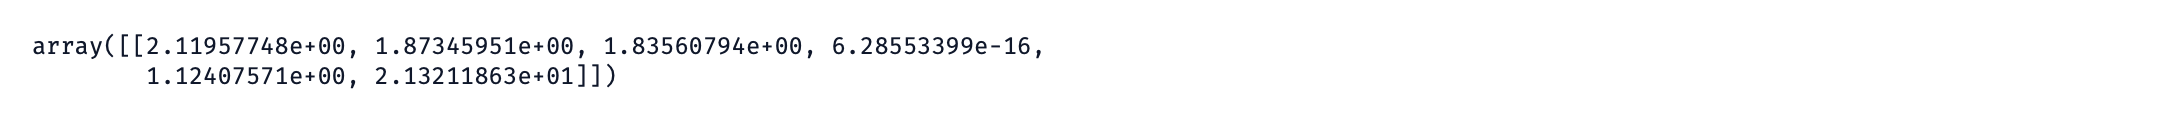

In [ ]:
x3

### Generate design matrix

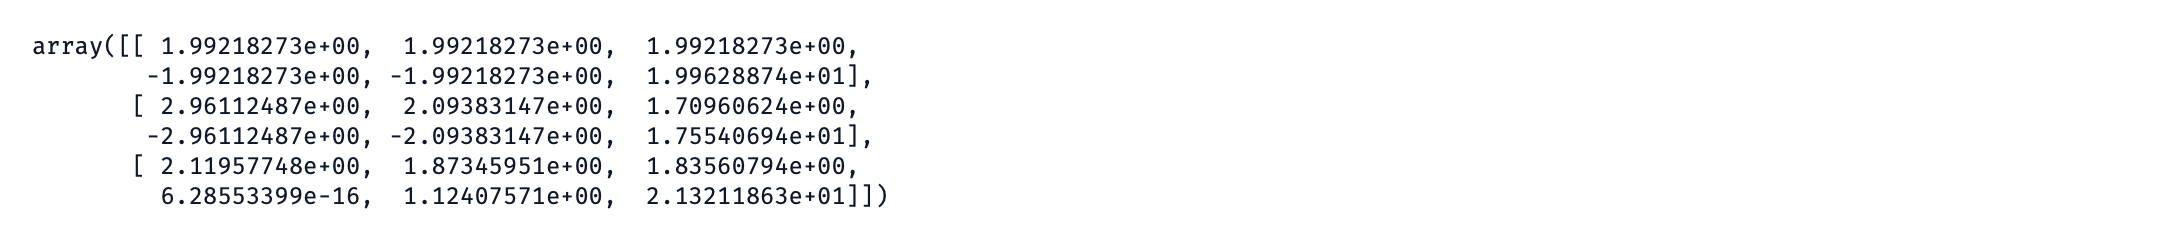

In [ ]:
design_matrix = np.concatenate((x1, x2, x3))
design_matrix

In [ ]:
# get 10 colors to use
colors = plt.cm.tab20.colors

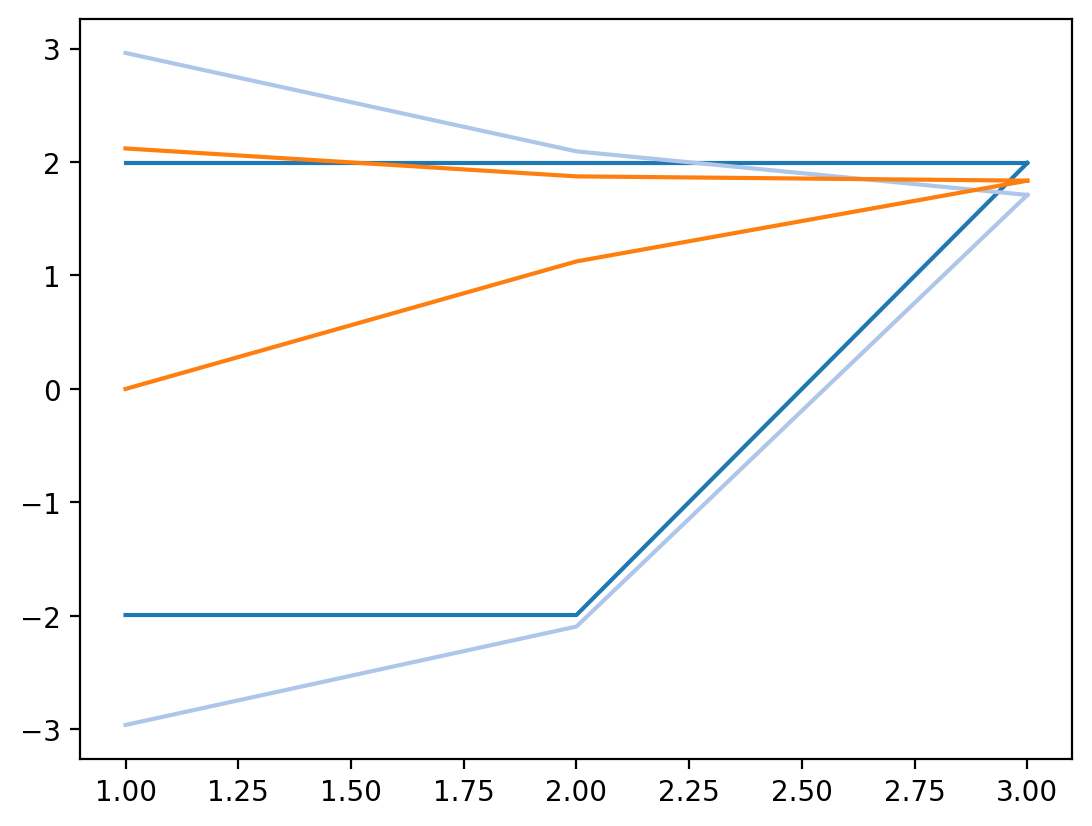

In [ ]:
_fig, _ax = plt.subplots()

for _i, _row in enumerate(design_matrix):
    _ax.plot([1,2,3], _row[0:3], color = colors[_i])
    _ax.plot([1,2,3], np.append(_row[3:5], _row[2]), color = colors[_i])

_fig

### Generate penalty output

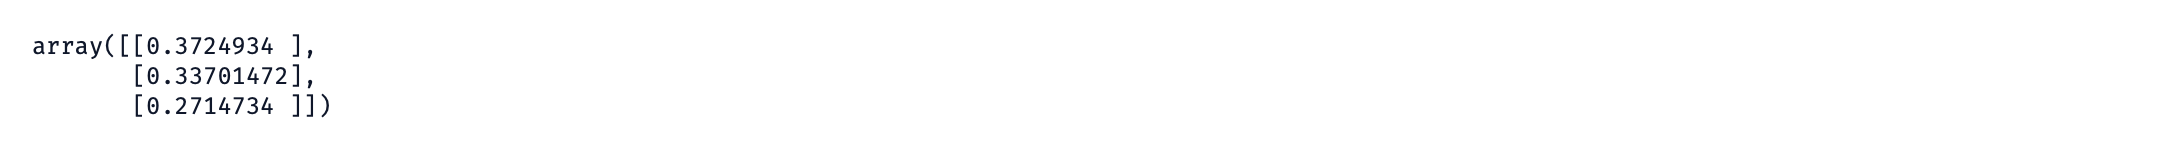

In [ ]:
output_vals = np.concatenate((y1, y2, y3))
output_vals

In [ ]:
initial_data = trieste.data.Dataset(
    query_points = design_matrix, 
    observations = output_vals
)

## GP regression model

In [ ]:
def build_model(X, Y, kernel, likelihood):

    gpr = gpflow.models.GPR(
        data = (X, Y),
        kernel = kernel,
        likelihood = likelihood
    )

    gpflow.utilities.print_summary(gpr, fmt="notebook")

    return GaussianProcessRegression(gpr)

In [ ]:
kernel = gpflow.kernels.Matern52()
#kernel.variance = gpflow.Parameter(value = 100, trainable = True)
kernel.lengthscales = gpflow.Parameter(value = [1, 1, 1, 1, 1, 1], trainable = True)

likelihood = gpflow.likelihoods.Gaussian()
#likelihood.variance = gpflow.Parameter(value = 10, trainable = False)

Starting the above kernel variance and likelihood variance at their default values to avoid Choleschy decomposition issues during `ask_tell` initialization.

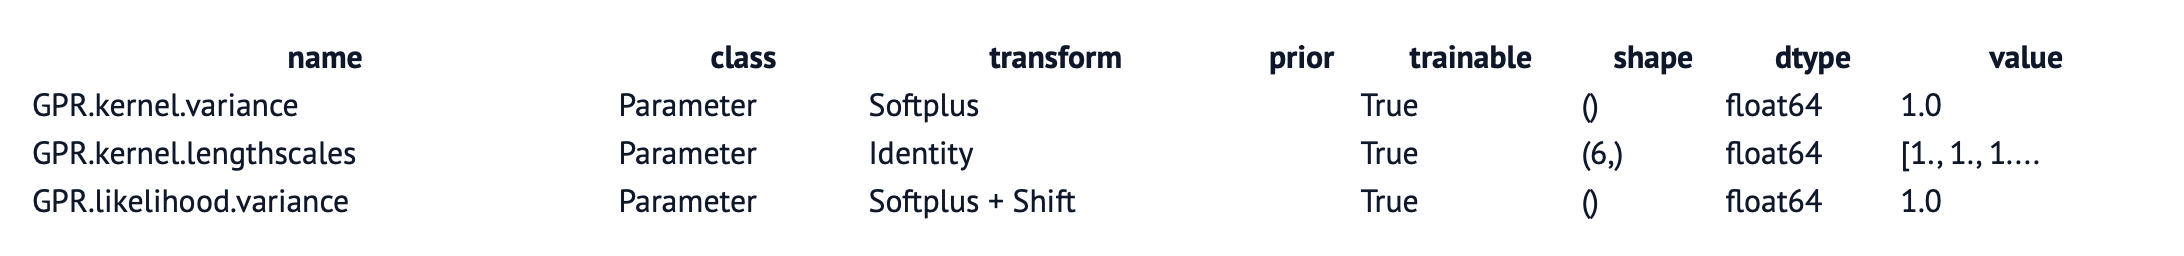

In [ ]:
bayes_opt_model = build_model(
    X = design_matrix, 
    Y = output_vals,
    kernel = kernel,
    likelihood = likelihood
)

## Define the search space

```
[
 [ 1.99218512e+00, 1.99218512e+00, 1.99218512e+00, -1.99218512e+00, -1.99218512e+00, 1.99629112e+01],
 [ 2.96112971e+00, 2.09383490e+00, 1.70960903e+00, -2.96112971e+00, -2.09383490e+00, 1.75540990e+01],
 [ 2.11957748e+00, 1.87345951e+00, 1.83560794e+00, 6.28553399e-16, 1.12407571e+00, 2.13211873e+01]
]
```

In [ ]:
_bounds = [1.99218512e+00, 1.99218512e+00, 1.99218512e+00, -1.99218512e+00, -1.99218512e+00]
lower = np.empty(6)
upper = np.empty(6)

for _i, _bound in enumerate(_bounds):
    lower[_i] = stats.norm.ppf(q=[0.3,0.7], loc=_bound, scale=0.5)[0]
    upper[_i] = stats.norm.ppf(q=[0.3,0.7], loc=_bound, scale=0.5)[1]

# add a single nan so it works with the plotting loops below
lower[5] = np.nan
upper[5] = np.nan

print(lower)
print(upper)

[ 1.72998486  1.72998486  1.72998486 -2.25438538 -2.25438538         nan]
[ 2.25438538  2.25438538  2.25438538 -1.72998486 -1.72998486         nan]


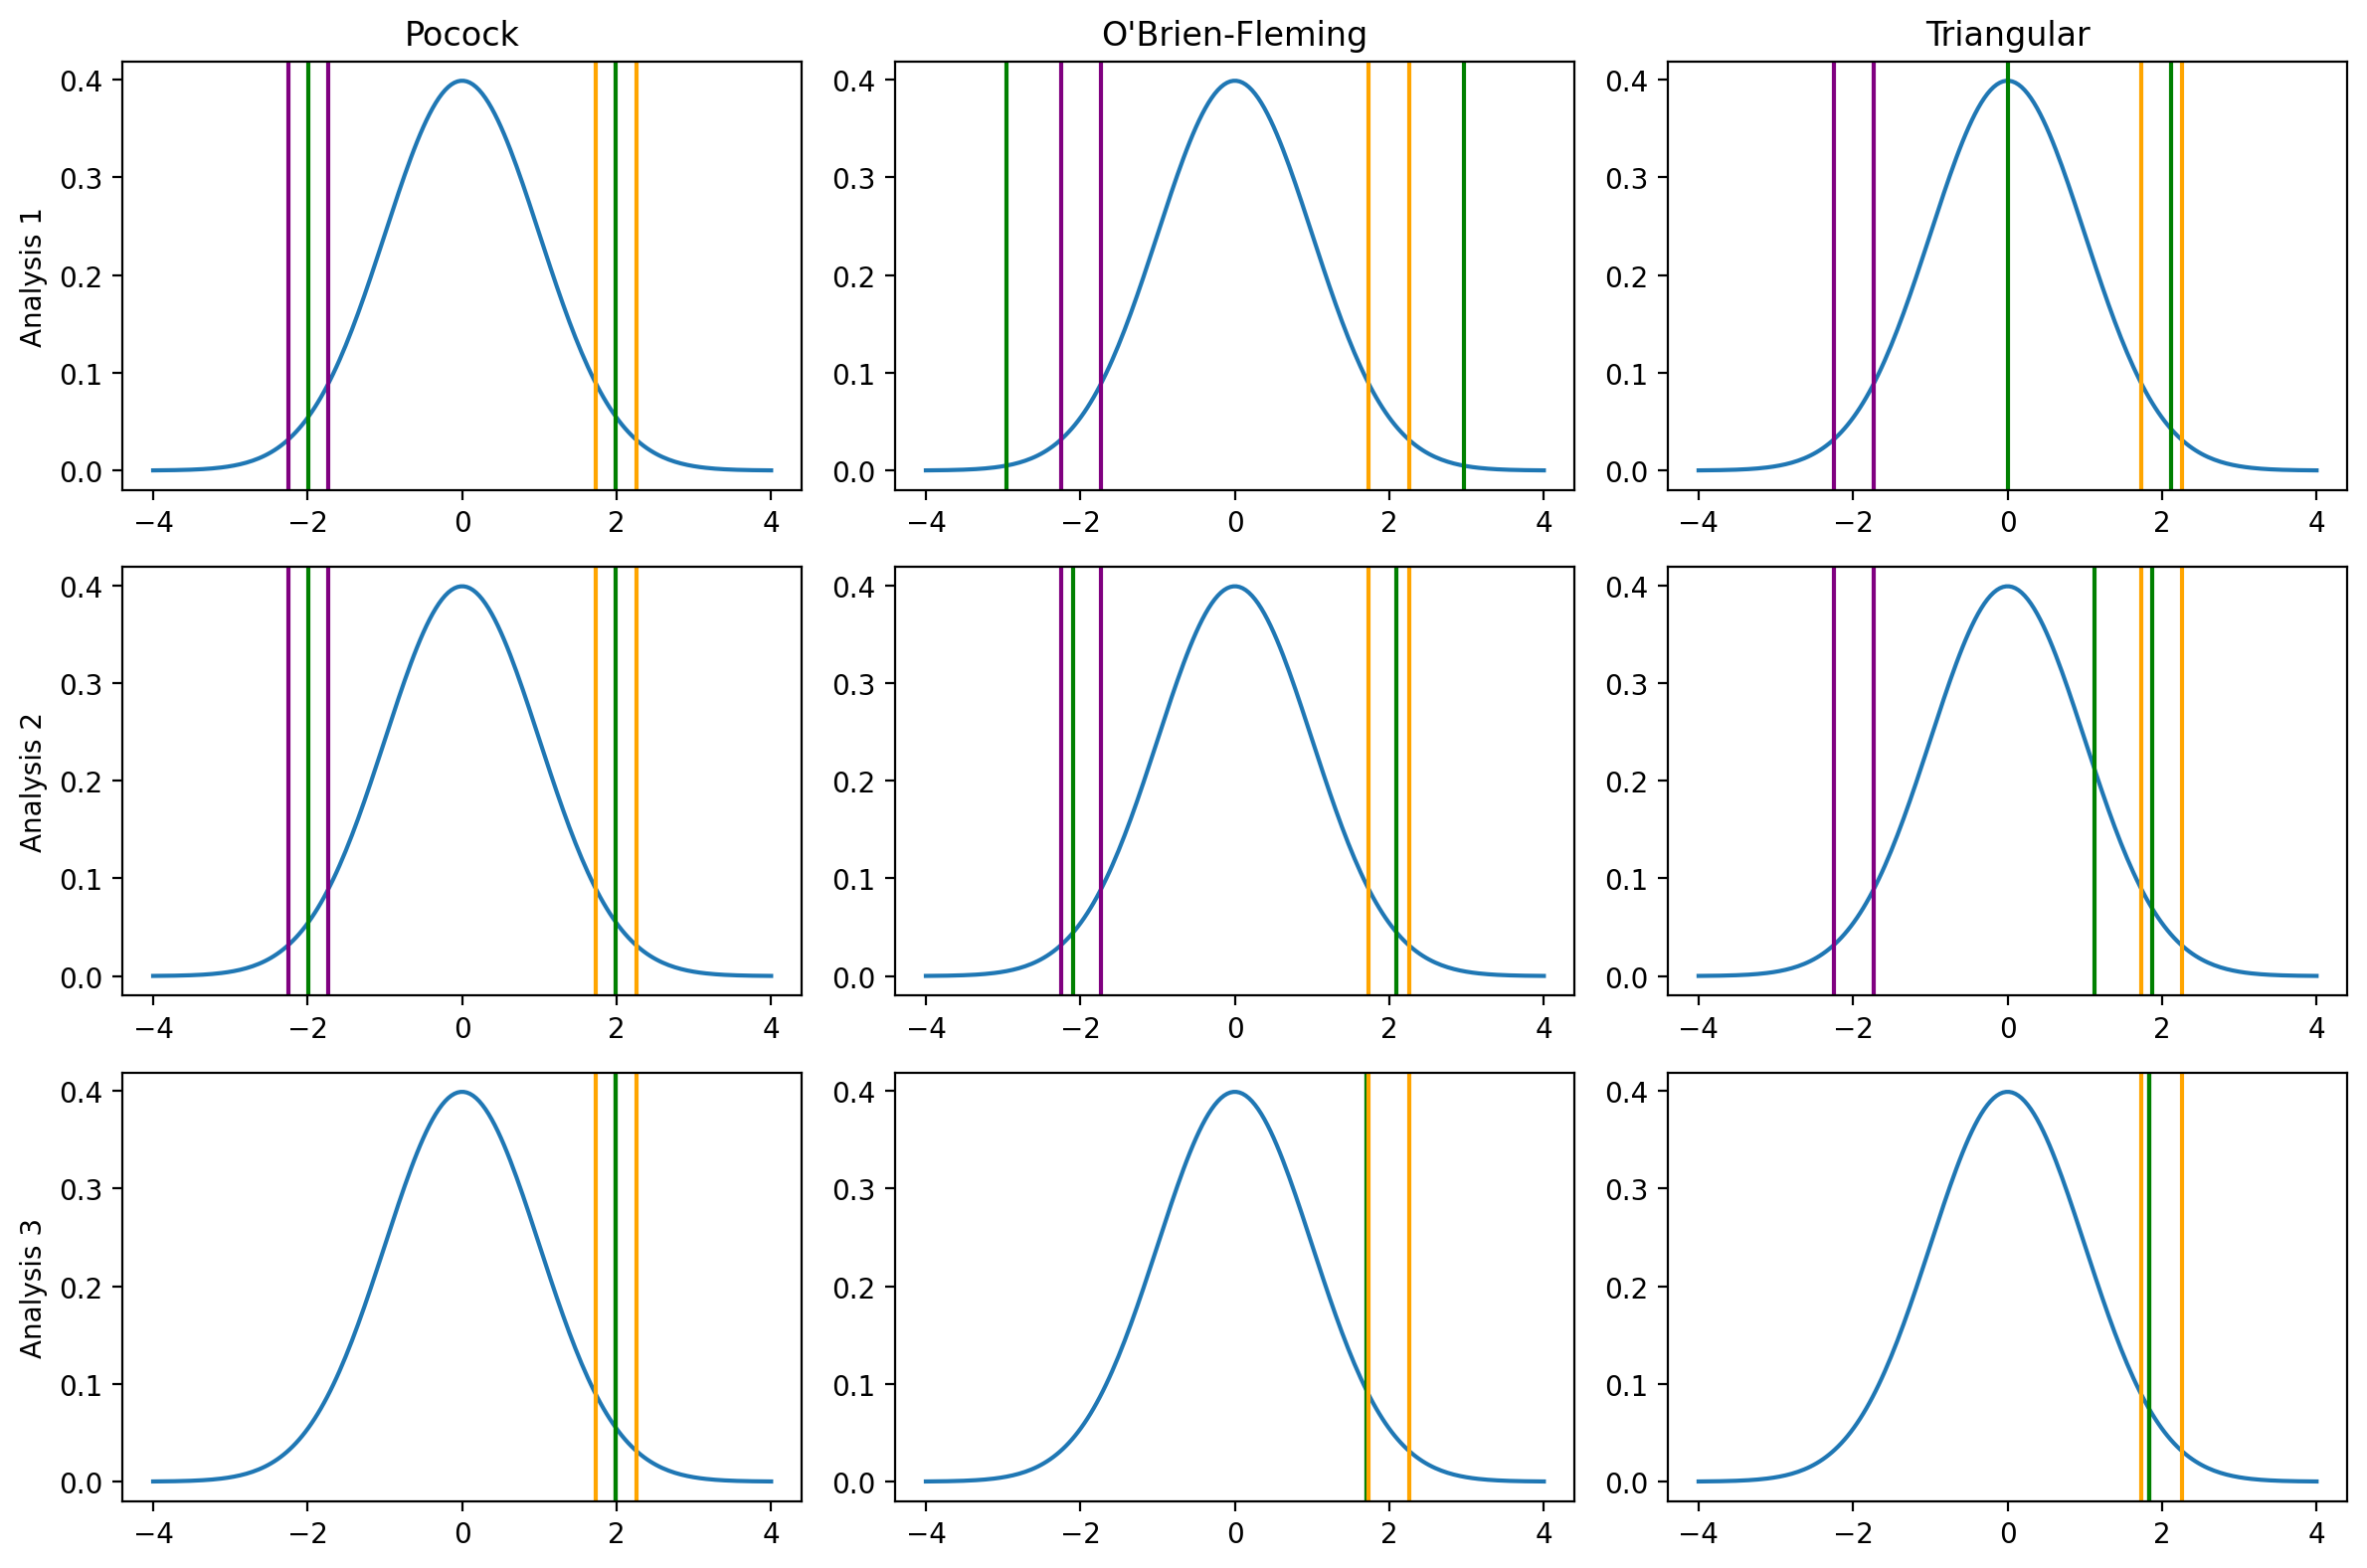

In [ ]:
_fig, _axes = plt.subplots(nrows=3, ncols=3, figsize=(12,8))
xx = np.linspace(start=-4, stop=4, num=200)

pocock_bounds = [ 1.99218512e+00, 1.99218512e+00, 1.99218512e+00, -1.99218512e+00, -1.99218512e+00, 1.99218512e+00]
of_bounds = [ 2.96112971e+00, 2.09383490e+00, 1.70960903e+00, -2.96112971e+00, -2.09383490e+00, 1.70960903e+00]
tri_bounds = [ 2.11957748e+00, 1.87345951e+00, 1.83560794e+00, 6.28553399e-16, 1.12407571e+00, 1.83560794e+00]
row_labels = ["Analysis 1", "Analysis 2", "Analysis 3"]
col_labels = ["Pocock", "O'Brien-Fleming", "Triangular"]

for _i in range(3):
    for _j in range(3):
        _axes[_i][_j].plot(xx, stats.norm.pdf(x=xx))

# plot the pocock bounds
for _i in range(3):
    _axes[_i,0].axvline(x=pocock_bounds[_i], color = "green")
    _axes[_i,0].axvline(x=pocock_bounds[_i+3], color = "green")

# plot the obrien-fleming bounds
for _i in range(3):
    _axes[_i,1].axvline(x=of_bounds[_i], color = "green")
    _axes[_i,1].axvline(x=of_bounds[_i+3], color = "green")

# plot the triangular bounds
for _i in range(3):
    _axes[_i,2].axvline(x=tri_bounds[_i], color = "green")
    _axes[_i,2].axvline(x=tri_bounds[_i+3], color = "green")

# plot possible boundaries
for _j in range(3):
    for _k in range(3):
        _axes[_k,_j].axvline(x=lower[_k], color = "orange")
        _axes[_k,_j].axvline(x=upper[_k], color = "orange")
        _axes[_k,_j].axvline(x=lower[_k+3], color = "purple")
        _axes[_k,_j].axvline(x=upper[_k+3], color = "purple")

# plot the titles
for _ax, _col in zip(_axes[0], col_labels):
    _ax.set_title(_col)
for _ax, _row in zip(_axes[:,0], row_labels):
    _ax.set_ylabel(_row)

_fig.tight_layout()
_fig

In [ ]:
# the search space is defined assuming a normal distribution with mean at triangular bound value
# and standard deviation of 0.5 (essentially a prior) and the bounds contain approximate
# probability density of 0.4
search_space = Box(
    lower = [1.72998486,  1.72998486,  1.72998486, -2.25438538, -2.25438538, 10], 
    upper = [2.25438538,  2.25438538,  2.25438538, -1.72998486, -1.72998486, 30]
)

## Initialize `ask_tell`

In [ ]:
ask_tell = trieste.ask_tell_optimization.AskTellOptimizer(
    search_space = search_space,
    datasets = initial_data,
    models = bayes_opt_model,
    acquisition_rule = trieste.acquisition.rule.EfficientGlobalOptimization(
        optimizer = 
          trieste.acquisition.optimizer.generate_continuous_optimizer(
            num_optimization_runs = 5000
        )
    )
)

## Bayes opt loop - without monotonicity penalty

In [ ]:
num_repeats = 700
when_to_print = 50

for _i in range(num_repeats):
    x_results = ask_tell.ask()

    new_inputs = fmt_bd.format_boundaries_after_ask(
        n_analyses = num_analyses,
        result = x_results
    )

    new_sim_trial = sim.group_sequential_designs(
        n_analyses = num_analyses,
        upper_bounds = new_inputs[0],
        lower_bounds = new_inputs[1],
        n_patients = new_inputs[2],
        null_hypothesis = 0,
        alt_hypothesis = important_diff_delta,
        variance = assumed_variance
    )

    new_x, new_y = generate_x_y(
        mu = mu,
        upper_bounds = new_inputs[0],
        lower_bounds= new_inputs[1],
        n_analyses = num_analyses,
        target_power = target_power,
        target_alpha = target_alpha,
        alpha_prime = new_sim_trial[1],
        beta_prime = 1-new_sim_trial[2],
        n_power09 = new_inputs[2]
    )

    new_data = trieste.data.Dataset(
        query_points = new_x, 
        observations = new_y
    )

    ask_tell.tell(new_data=new_data)

    if (_i+1) % when_to_print == 0:
        print(f"Loop {_i+1} completed.")

Loop 50 completed.
Loop 100 completed.
Loop 150 completed.
Loop 200 completed.
Loop 250 completed.


Loop 300 completed.
Loop 350 completed.
Loop 400 completed.
Loop 450 completed.


Loop 500 completed.
Loop 550 completed.
Loop 600 completed.
Loop 650 completed.
Loop 700 completed.


In [ ]:
plt.hist(ask_tell.to_result().try_get_final_dataset().observations, bins=50)

In [ ]:
lt_3 = tf.squeeze(ask_tell.to_result().try_get_final_dataset().observations < 2)

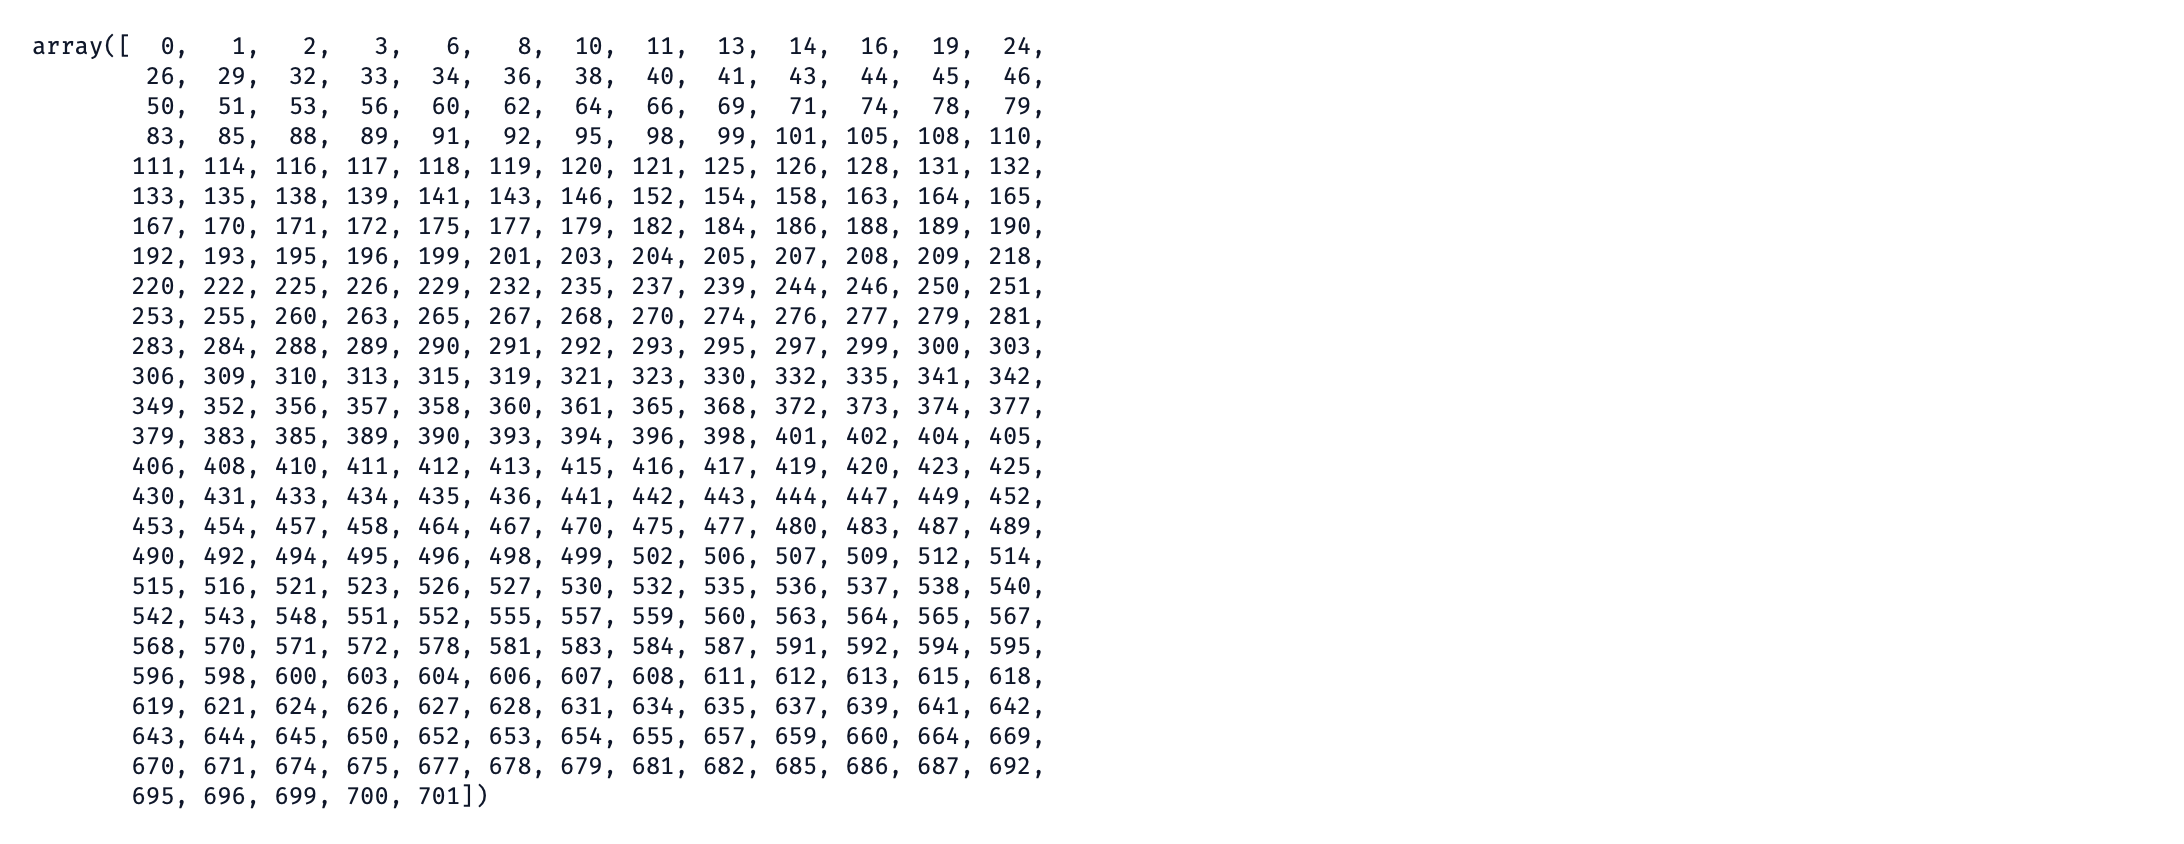

In [ ]:
np.where(lt_3)[0]

In [ ]:
fmt_bd.format_boundaries_after_ask(n_analyses=3, result=np.array([[ 2.11957748e+00,  1.87345951e+00,  1.83560794e+00,
         6.28553399e-16,  1.12407571e+00,  2.13211873e+01]]))

In [ ]:
monotonic = []
for _bounds in ask_tell.to_result().try_get_final_dataset().query_points:
    monotonic.append(fmt_bd.check_monotonicity(n_analyses=3, bounds=_bounds))

In [ ]:
idx = np.where(np.array(monotonic) & lt_3)

In [ ]:
idx

In [ ]:
best_monotonic_bounds = np.array(ask_tell.to_result().try_get_final_dataset().query_points)[idx]

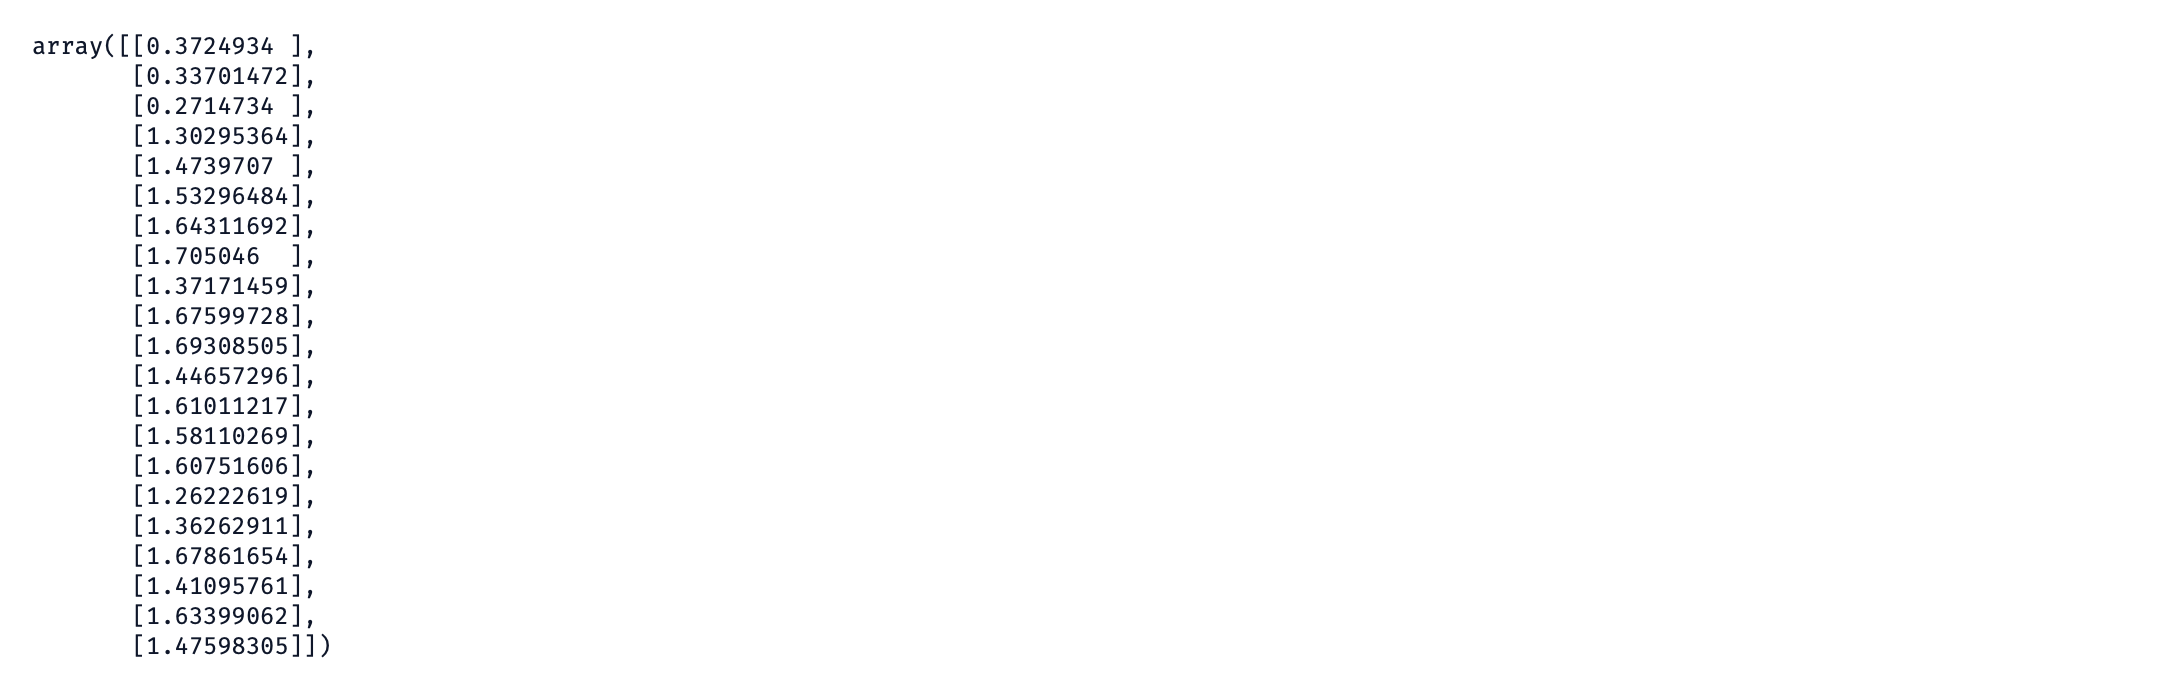

In [ ]:
np.array(ask_tell.to_result().try_get_final_dataset().observations)[idx]

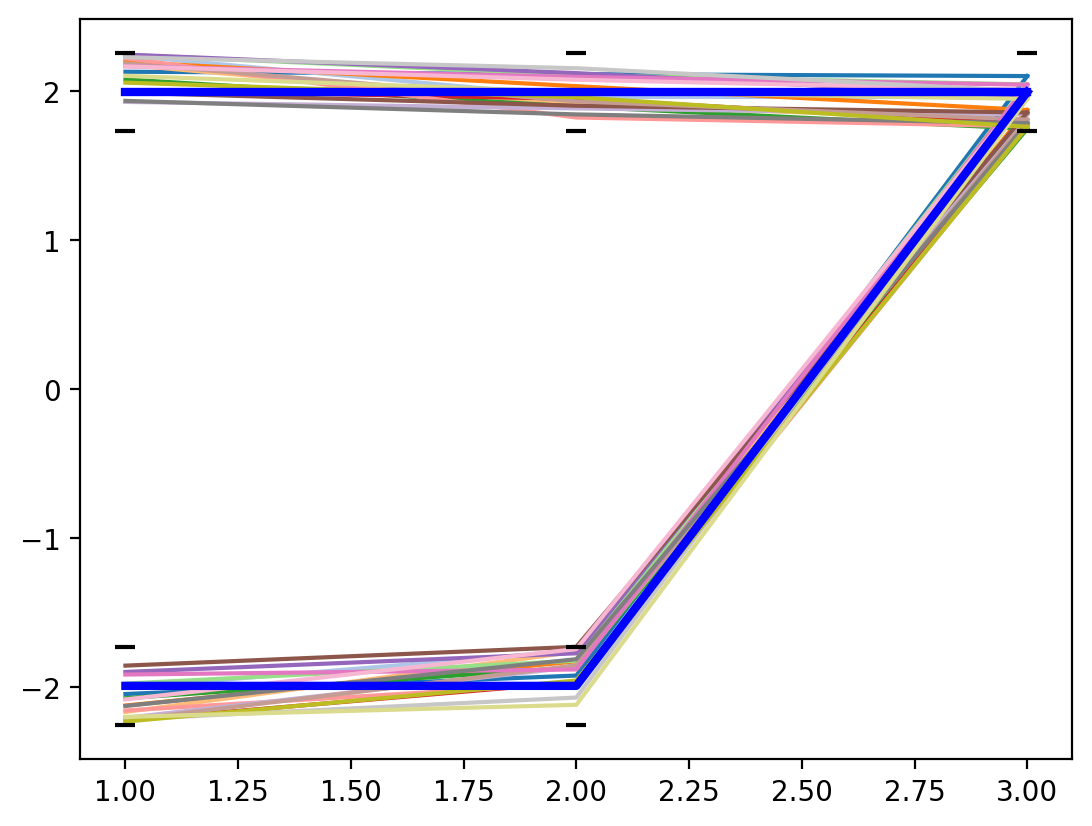

In [ ]:
_fig, _ax = plt.subplots()

for _i, _bounds in enumerate(best_monotonic_bounds[3:len(best_monotonic_bounds)]):
    _ax.plot([1,2,3], _bounds[0:3], color = colors[_i])
    _ax.plot([1,2,3], np.append(_bounds[3:5], _bounds[2]), color = colors[_i])

_ax.plot([1,2,3], best_monotonic_bounds[0][0:3], linewidth=3, color="blue")
_ax.plot([1,2,3], np.append(best_monotonic_bounds[0][3:5], best_monotonic_bounds[0][2]), linewidth=3, color="blue")

# plot the constraints
_ax.scatter([1,1,1,1], [1.72998486,2.25438538,-2.25438538,-1.72998486], marker="_", color="black", s=50, zorder=3)
_ax.scatter([2,2,2,2], [1.72998486,2.25438538,-2.25438538,-1.72998486], marker="_", color="black", s=50, zorder=3)
_ax.scatter([3,3], [1.72998486,2.25438538], marker="_", color="black", s=50, zorder=3)

_fig

In [ ]:
slider = mo.ui.slider(start=1, stop=len(best_monotonic_bounds)-1, step=1)

In [ ]:
slider

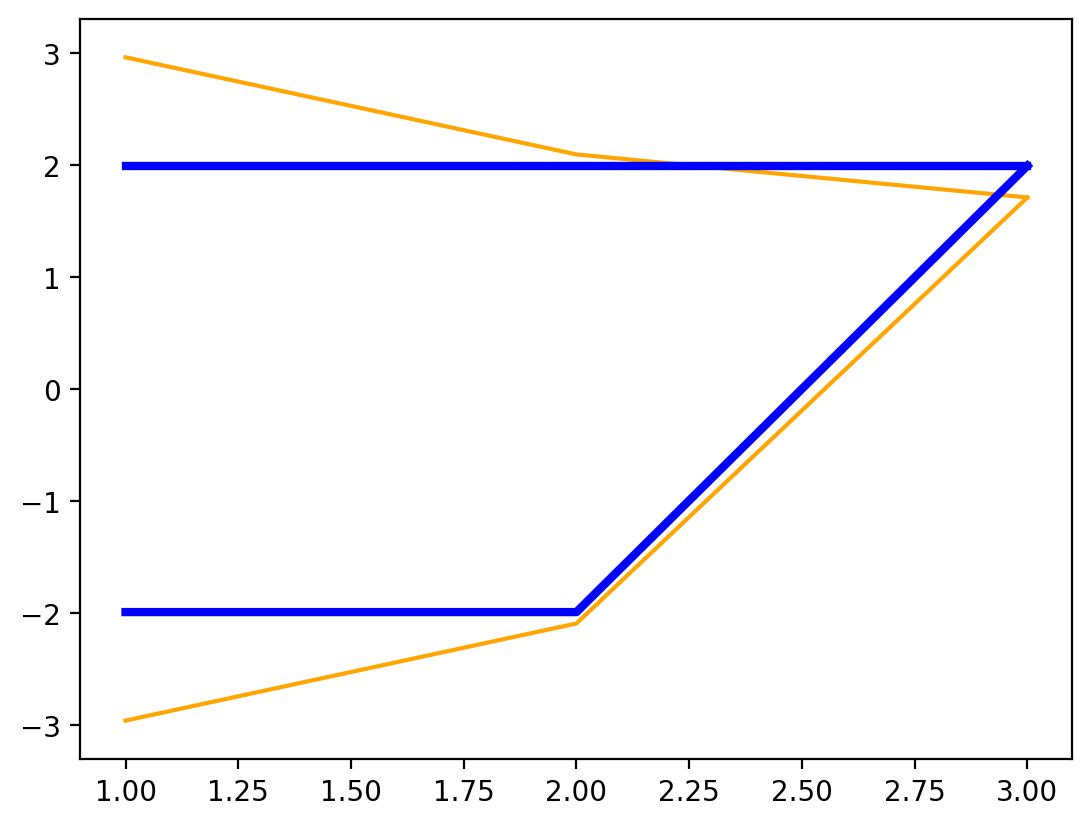

In [ ]:
_fig, _ax = plt.subplots()

_bounds = best_monotonic_bounds[slider.value]
_ax.plot([1,2,3], _bounds[0:3], color = "orange")
_ax.plot([1,2,3], np.append(_bounds[3:5], _bounds[2]), color = "orange")

_ax.plot([1,2,3], best_monotonic_bounds[0][0:3], linewidth=3, color="blue")
_ax.plot([1,2,3], np.append(best_monotonic_bounds[0][3:5], best_monotonic_bounds[0][2]), linewidth=3, color="blue")

_ax.set_ylim(-3.3,3.3)

_fig

## GP model assessment

In [ ]:
gpflow.utilities.print_summary(ask_tell.model.model)

╒═════════════════════════╤══════════════════╤══════════════════╤═════════╤═════════════╤═══════════╤═════════╤═════════════════════════════════════════════════════╕
│ name                    │ class            │ transform        │ prior   │ trainable   │ shape     │ dtype   │ value                                               │
╞═════════════════════════╪══════════════════╪══════════════════╪═════════╪═════════════╪═══════════╪═════════╪═════════════════════════════════════════════════════╡
│ GPR.kernel.variance     │ Parameter        │ Softplus         │         │ True        │ ()        │ float64 │ 54.3724                                             │
├─────────────────────────┼──────────────────┼──────────────────┼─────────┼─────────────┼───────────┼─────────┼─────────────────────────────────────────────────────┤
│ GPR.kernel.lengthscales │ Parameter        │ Identity         │         │ True        │ (6,)      │ float64 │ [1.35793530e+03, 1.85448983e+03, -4.30780068e-04... │
├───

## Bayes opt loop - with monotonicity penalty

In [ ]:
ask_tell1 = trieste.ask_tell_optimization.AskTellOptimizer(
    search_space = search_space,
    datasets = initial_data,
    models = bayes_opt_model,
    acquisition_rule = trieste.acquisition.rule.EfficientGlobalOptimization(
        optimizer = 
          trieste.acquisition.optimizer.generate_continuous_optimizer(
            num_optimization_runs = 5000
        )
    )
)

In [ ]:
for _i in range(num_repeats):
    x_results1 = ask_tell1.ask()

    new_inputs1 = fmt_bd.format_boundaries_after_ask(
        n_analyses = num_analyses,
        result = x_results1
    )

    new_sim_trial1 = sim.group_sequential_designs(
        n_analyses = num_analyses,
        upper_bounds = new_inputs1[0],
        lower_bounds = new_inputs1[1],
        n_patients = new_inputs1[2],
        null_hypothesis = 0,
        alt_hypothesis = important_diff_delta,
        variance = assumed_variance
    )

    new_x1, new_y1 = generate_x_y_new(
        mu = mu,
        upper_bounds = new_inputs1[0],
        lower_bounds= new_inputs1[1],
        n_analyses = num_analyses,
        target_power = target_power,
        target_alpha = target_alpha,
        alpha_prime = new_sim_trial1[1],
        beta_prime = 1-new_sim_trial1[2],
        n_power09 = new_inputs1[2]
    )

    new_data1 = trieste.data.Dataset(
        query_points = new_x1, 
        observations = new_y1
    )

    ask_tell1.tell(new_data=new_data1)

    if (_i+1) % when_to_print == 0:
        print(f"Loop {_i+1} completed.")

Loop 50 completed.
Loop 100 completed.
Loop 150 completed.
Loop 200 completed.
Loop 250 completed.
Loop 300 completed.
Loop 350 completed.
Loop 400 completed.
Loop 450 completed.
Loop 500 completed.
Loop 550 completed.
Loop 600 completed.
Loop 650 completed.
Loop 700 completed.


In [ ]:
not_25 = ask_tell1.to_result().try_get_final_dataset().observations != 25

In [ ]:
plt.hist(ask_tell1.to_result().try_get_final_dataset().observations, bins=50)

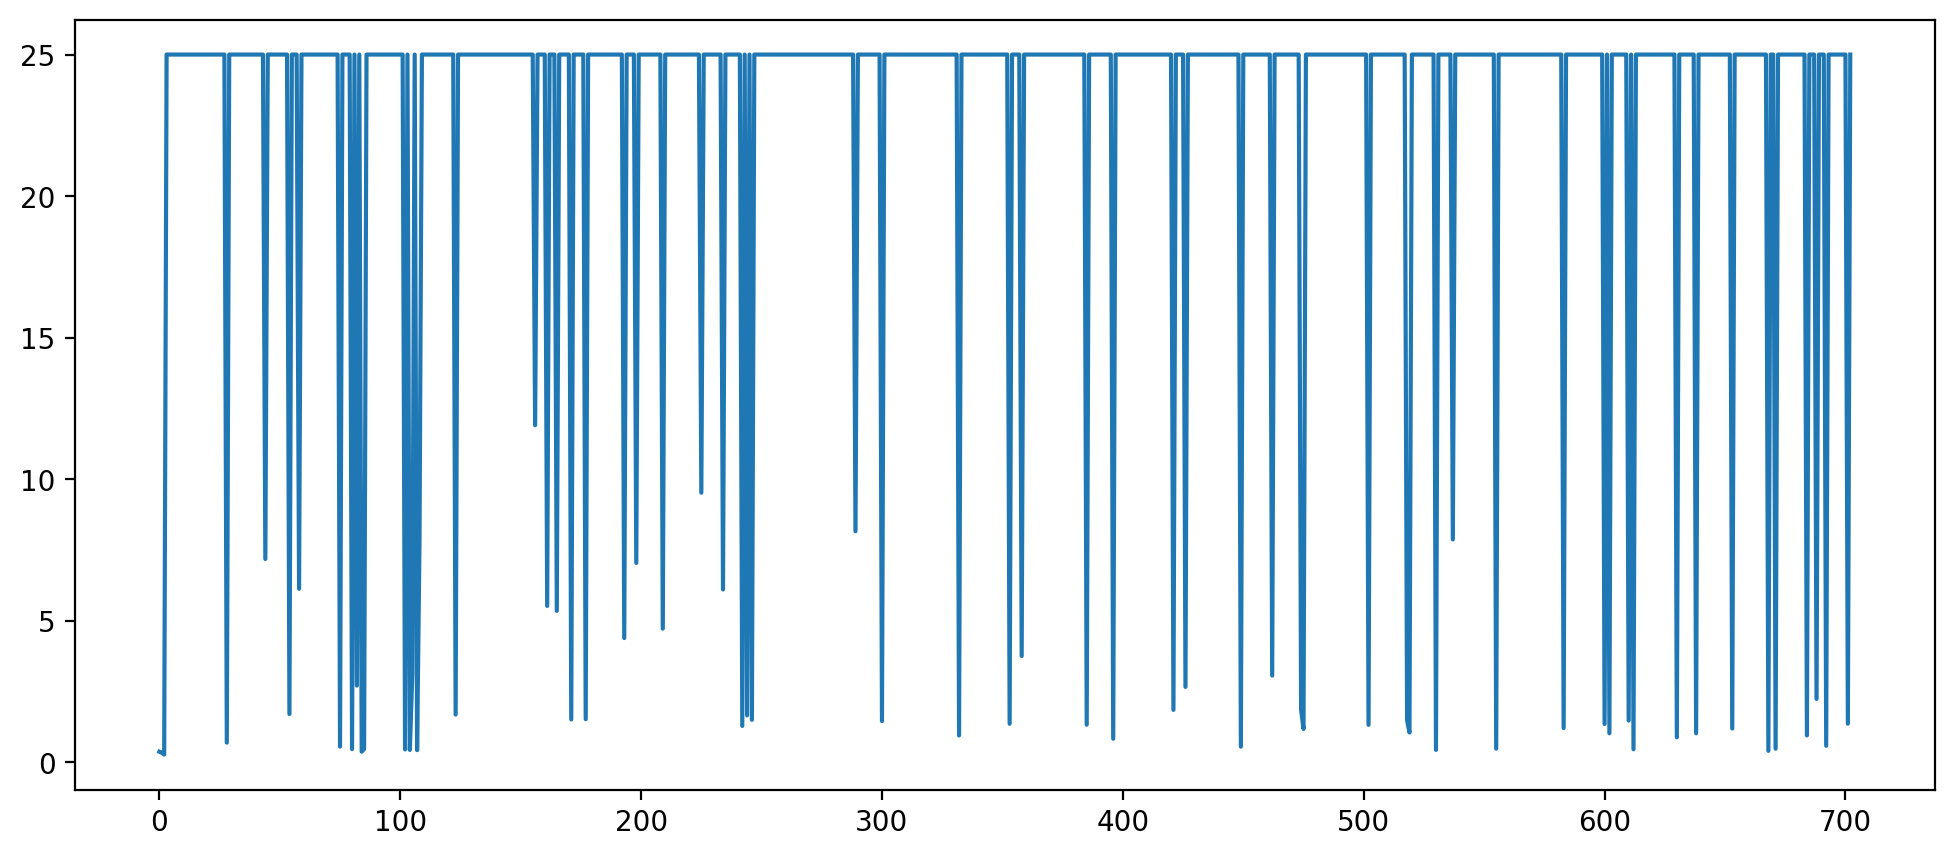

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(ask_tell1.to_result().try_get_final_dataset().observations)

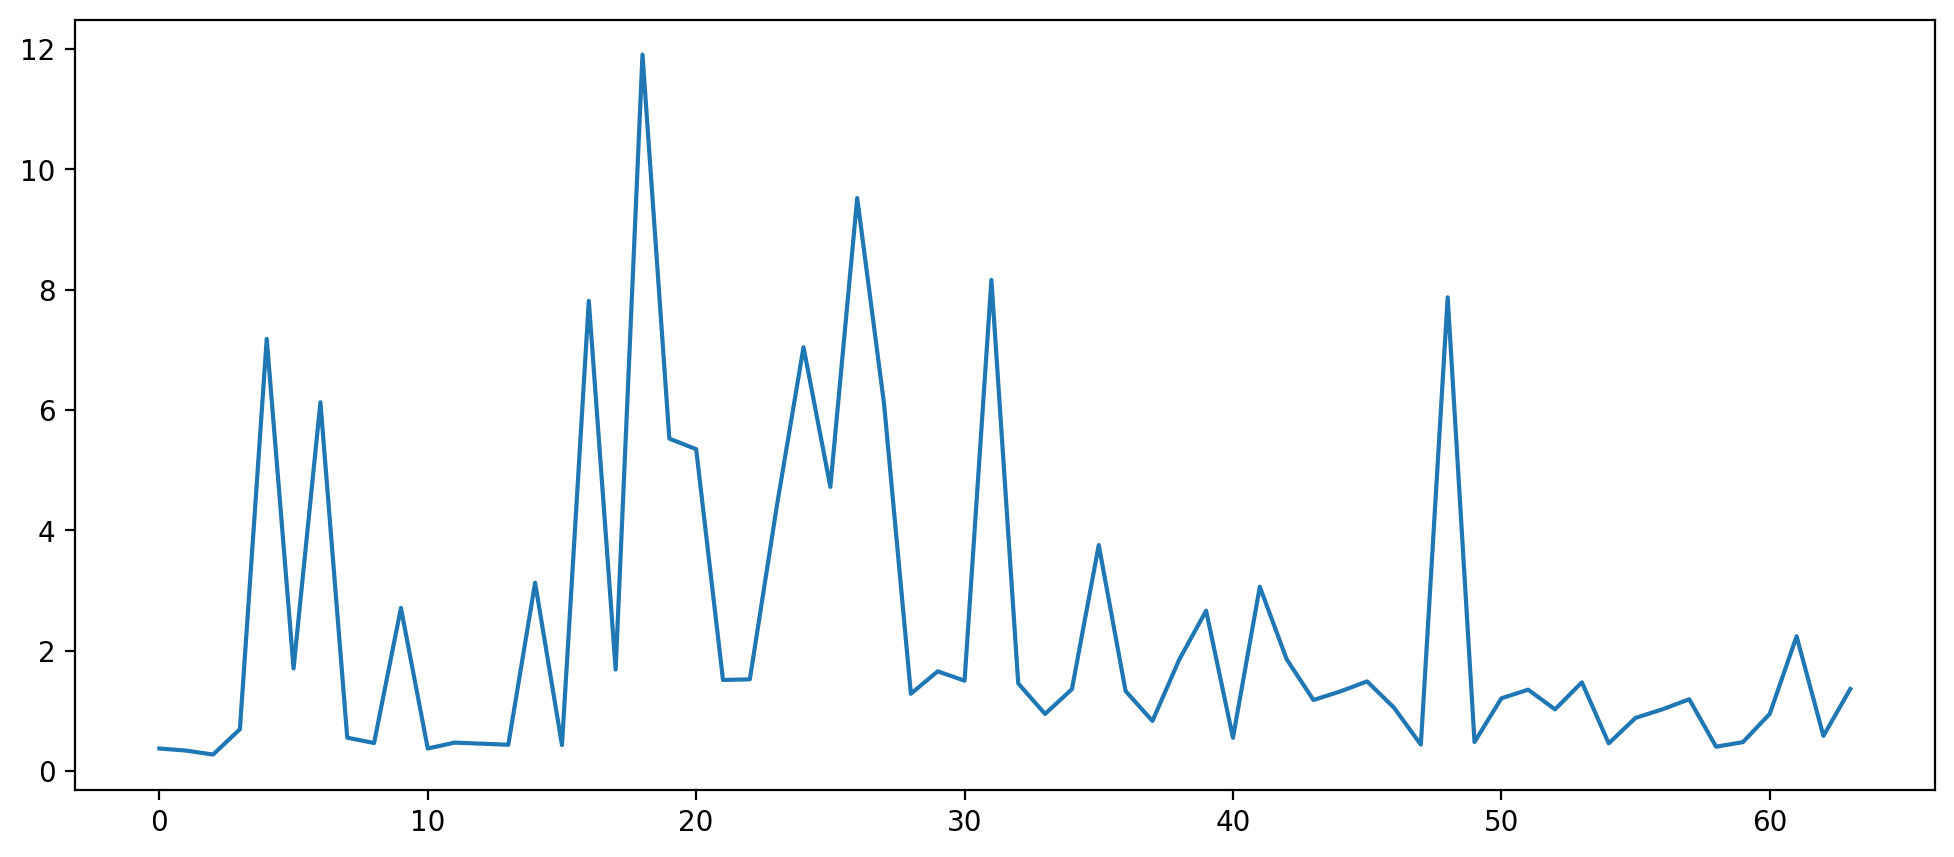

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(ask_tell1.to_result().try_get_final_dataset().observations[not_25])

In [ ]:
plt.hist(ask_tell1.to_result().try_get_final_dataset().observations[not_25], bins=50)

In [ ]:
lt_03 = tf.squeeze(ask_tell1.to_result().try_get_final_dataset().observations < 0.5)

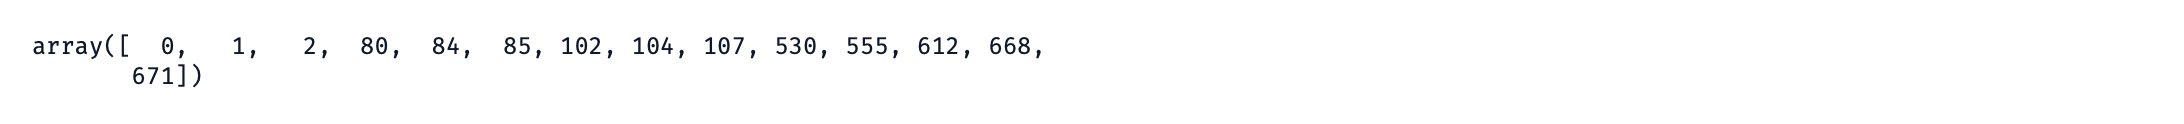

In [ ]:
np.where(lt_03)[0]

In [ ]:
monotonic1 = []
for _bounds in ask_tell1.to_result().try_get_final_dataset().query_points:
    monotonic1.append(fmt_bd.check_monotonicity(n_analyses=3, bounds=_bounds))

In [ ]:
idx1 = np.where(np.array(monotonic1) & lt_03)

In [ ]:
idx1

In [ ]:
best_monotonic_bounds1 = np.array(ask_tell1.to_result().try_get_final_dataset().query_points)[idx1]

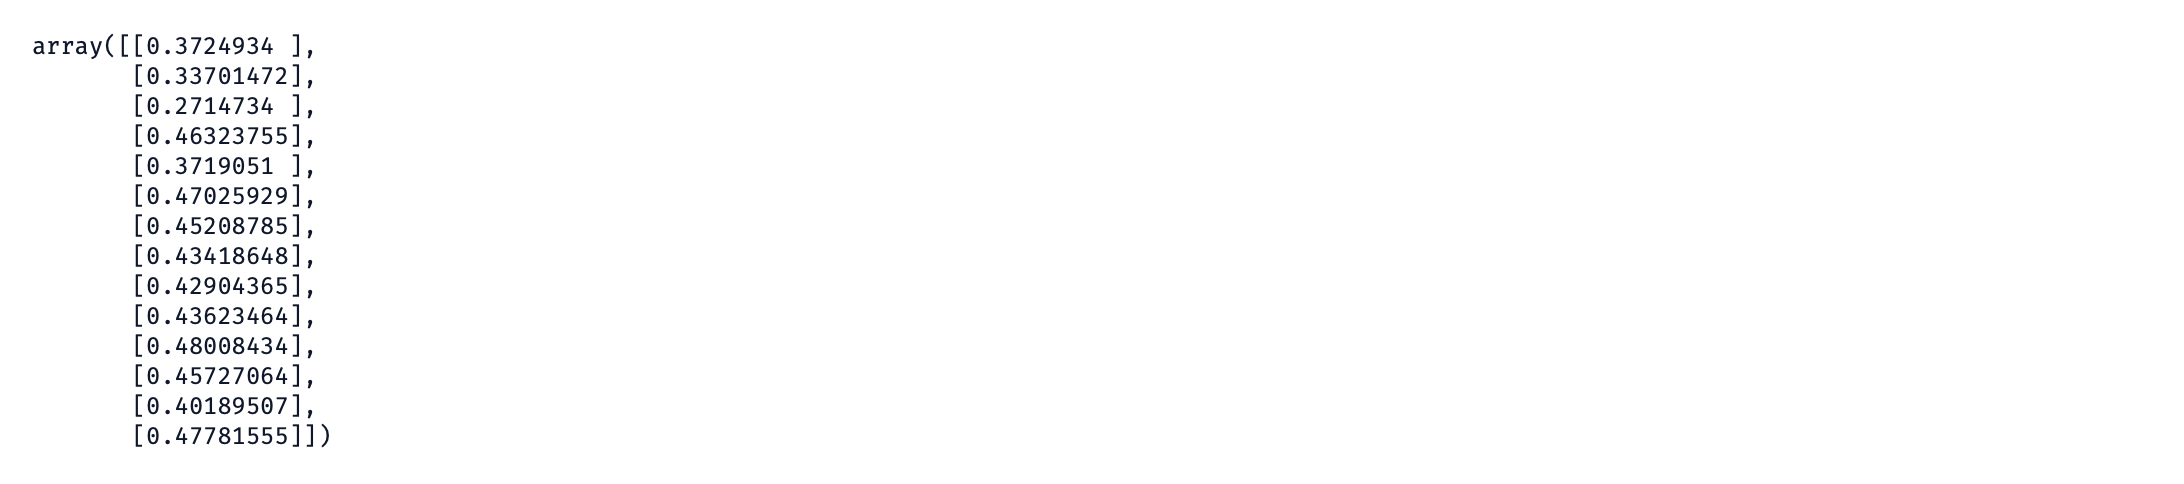

In [ ]:
np.array(ask_tell1.to_result().try_get_final_dataset().observations)[idx1]

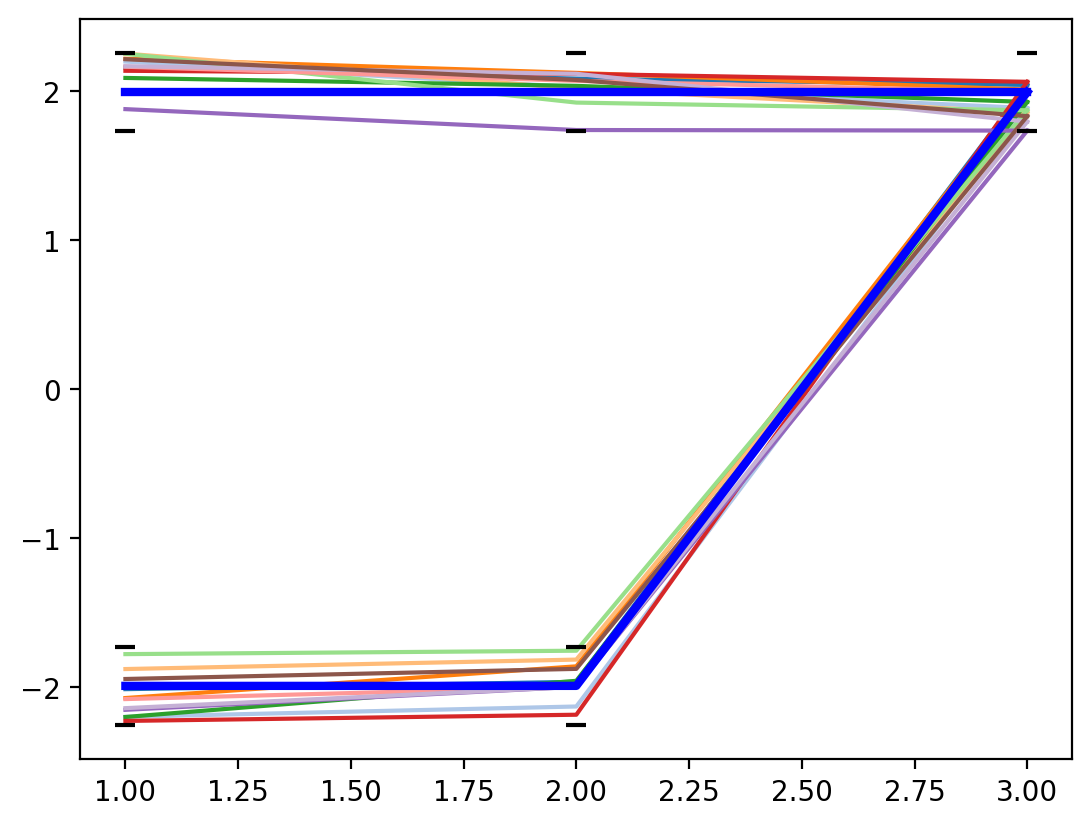

In [ ]:
_fig, _ax = plt.subplots()

# plot all the bounds that were monotonic and near the pocock cost
for _i, _bounds in enumerate(best_monotonic_bounds1[3:len(best_monotonic_bounds1)]):
    _ax.plot([1,2,3], _bounds[0:3], color = colors[_i])
    _ax.plot([1,2,3], np.append(_bounds[3:5], _bounds[2]), color = colors[_i])

# plot the pocock bounds for reference
_ax.plot([1,2,3], best_monotonic_bounds1[0][0:3], linewidth=3, color="blue")
_ax.plot([1,2,3], np.append(best_monotonic_bounds1[0][3:5], best_monotonic_bounds1[0][2]), linewidth=3, color="blue")

# plot the constraints
_ax.scatter([1,1,1,1], [1.72998486,2.25438538,-2.25438538,-1.72998486], marker="_", color="black", s=50, zorder=3)
_ax.scatter([2,2,2,2], [1.72998486,2.25438538,-2.25438538,-1.72998486], marker="_", color="black", s=50, zorder=3)
_ax.scatter([3,3], [1.72998486,2.25438538], marker="_", color="black", s=50, zorder=3)

_fig

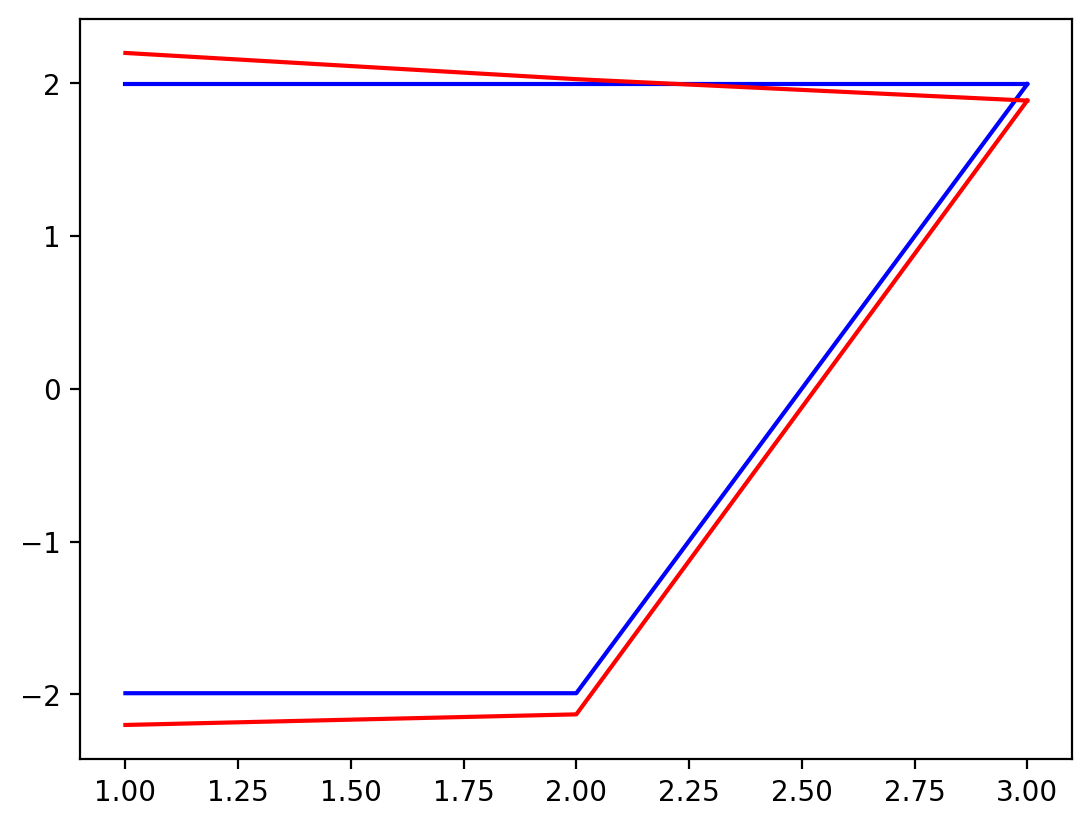

In [ ]:
_fig, _ax = plt.subplots()

# plot the pocock bounds for reference
_ax.plot([1,2,3], best_monotonic_bounds1[0][0:3], color="blue")
_ax.plot([1,2,3], np.append(best_monotonic_bounds1[0][3:5], best_monotonic_bounds1[0][2]), color="blue")

# plot the bounds nearest pocock
_ax.plot([1,2,3], best_monotonic_bounds1[4][0:3], color="red")
_ax.plot([1,2,3], np.append(best_monotonic_bounds1[4][3:5], best_monotonic_bounds1[4][2]), color="red")

In [ ]:
slider1 = mo.ui.slider(start=1, stop=len(best_monotonic_bounds1)-1, step=1)

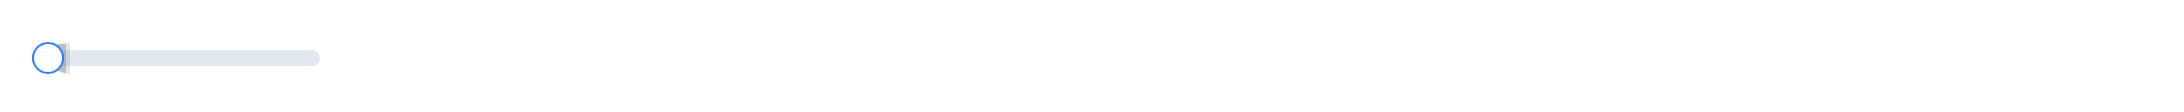

In [ ]:
slider1

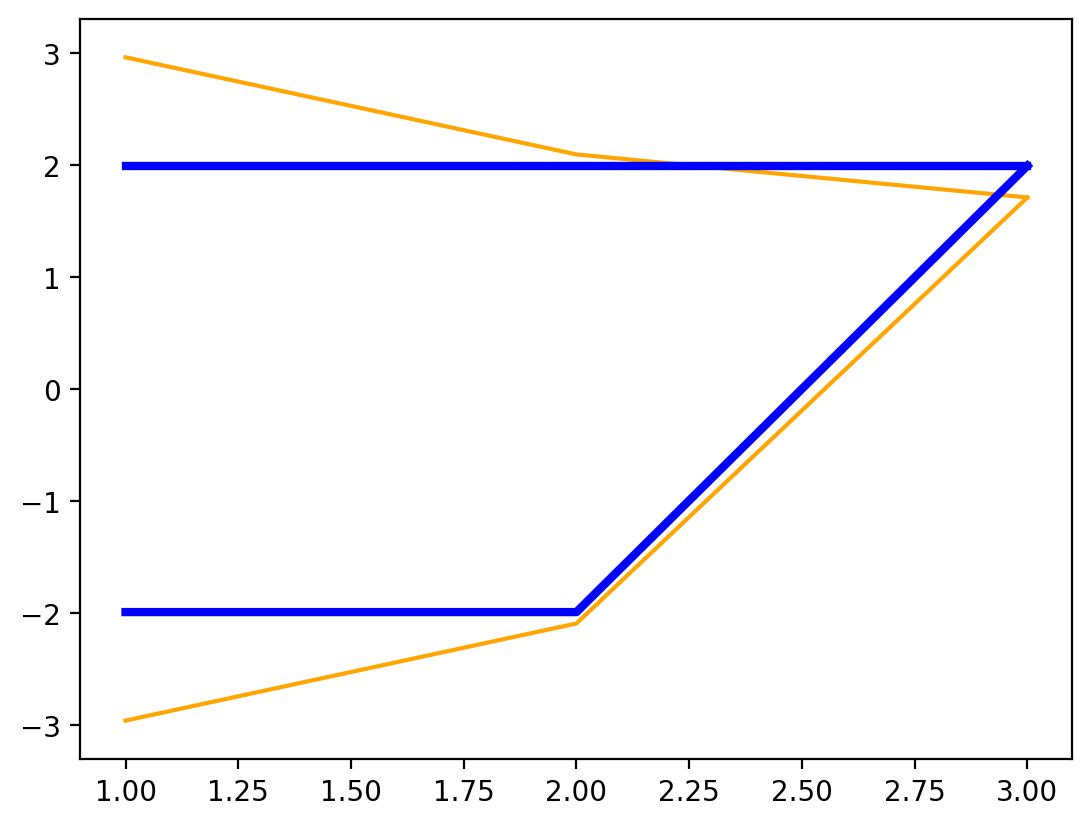

In [ ]:
_fig, _ax = plt.subplots()

_bounds = best_monotonic_bounds1[slider1.value]
_ax.plot([1,2,3], _bounds[0:3], color = "orange")
_ax.plot([1,2,3], np.append(_bounds[3:5], _bounds[2]), color = "orange")

_ax.plot([1,2,3], best_monotonic_bounds1[0][0:3], linewidth=3, color="blue")
_ax.plot([1,2,3], np.append(best_monotonic_bounds1[0][3:5], best_monotonic_bounds1[0][2]), linewidth=3, color="blue")

_ax.set_ylim(-3.3,3.3)

_fig

## GP model assessment

In [ ]:
gpflow.utilities.print_summary(ask_tell1.model.model)

╒═════════════════════════╤══════════════════╤══════════════════╤═════════╤═════════════╤═══════════╤═════════╤═════════════════════════════════════════════════════╕
│ name                    │ class            │ transform        │ prior   │ trainable   │ shape     │ dtype   │ value                                               │
╞═════════════════════════╪══════════════════╪══════════════════╪═════════╪═════════════╪═══════════╪═════════╪═════════════════════════════════════════════════════╡
│ GPR.kernel.variance     │ Parameter        │ Softplus         │         │ True        │ ()        │ float64 │ 563.65259                                           │
├─────────────────────────┼──────────────────┼──────────────────┼─────────┼─────────────┼───────────┼─────────┼─────────────────────────────────────────────────────┤
│ GPR.kernel.lengthscales │ Parameter        │ Identity         │         │ True        │ (6,)      │ float64 │ [1.35793530e+03, 1.85448983e+03, -2.69398089e-05... │
├───

# Save the model runs

## Without monotonicity constrait

In [ ]:
bounds_no_monotonicity = pd.DataFrame(
    data=ask_tell.to_result().try_get_final_dataset().query_points,
    columns=["upper1","upper2","upper3","lower1","lower2","n"]
)

In [ ]:
penalty_no_monotonicity = pd.DataFrame(
    data=ask_tell.to_result().try_get_final_dataset().observations,
    columns=["penalty"]
)

In [ ]:
no_monotonicity = pd.concat([bounds_no_monotonicity, penalty_no_monotonicity], axis=1)

In [ ]:
no_monotonicity.to_csv(path_or_buf="/tf/2026-03-t15/pocock_no_monotonicity.csv", index=False)

## With monotonicity constraint

In [ ]:
bounds_monotonicity = pd.DataFrame(
    data=ask_tell1.to_result().try_get_final_dataset().query_points,
    columns=["upper1","upper2","upper3","lower1","lower2","n"]
)

In [ ]:
penalty_monotonicity = pd.DataFrame(
    data=ask_tell1.to_result().try_get_final_dataset().observations,
    columns=["penalty"]
)

In [ ]:
monotonicity = pd.concat([bounds_monotonicity, penalty_monotonicity], axis=1)

In [ ]:
monotonicity.to_csv(path_or_buf="/tf/2026-03-t15/pocock_monotonicity.csv", index=False)